In [10]:
# pip install pandas numpy scikit-learn matplotlib

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("datacopy.csv")

df.columns = [
    "cal_bp",
    "c14_age",
    "c14_sigma",
    "delta14c",
    "delta_sigma"
]

print(df.head())
print(df.shape)

   cal_bp  c14_age  c14_sigma  delta14c  delta_sigma
0   55000    50100       1024     528.5        193.9
1   54980    50081       1018     528.3        192.7
2   54960    50063       1013     527.9        191.7
3   54940    50043       1007     527.8        190.6
4   54920    50027       1003     527.0        189.5
(9501, 5)


F14C=1+Δ14C/1000​

In [12]:
df["F14C"] = 1 + df["delta14c"]/1000 #This represents the relative C14/C12 ratio.

t=−8033ln(F14C)


In [13]:
df["theoretical_c14_age"] = -8033 * np.log(df["F14C"]) #This gives the raw decay age without calibration.

In [14]:
df.head()

,cal_bp,c14_age,c14_sigma,delta14c,delta_sigma,F14C,theoretical_c14_age
0,55000,50100,1024,528.5,193.9,1.5285,-3408.296365
1,54980,50081,1018,528.3,192.7,1.5283,-3407.245201
2,54960,50063,1013,527.9,191.7,1.5279,-3405.142459
3,54940,50043,1007,527.8,190.6,1.5278,-3404.616687
4,54920,50027,1003,527.0,189.5,1.5270,-3400.409276


Compute Calibration Offset

offset=CAL_BP−14C_age

c14_age = 50100
cal_bp = 55000

offset = 4900

In [15]:
df["offset"] = df["cal_bp"] - df["c14_age"]

Inputs (features):

F14C
c14_age
delta14c

Target:

offset

In [16]:
from sklearn.model_selection import train_test_split

X = df[["F14C","c14_age","delta14c"]]
y = df["offset"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We’ll use Random Forest (good for nonlinear data).

In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Evaluate Accuracy

In [22]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)

print("Average calibration error:", mae, "years")

Average calibration error: 2.679572374189023 years


In [31]:
X1 = df[['c14_age']]
y1 = df['cal_bp']

In [32]:
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestRegressor

model1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model1.fit(X_train1, y_train1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [34]:
from sklearn.metrics import mean_absolute_error

predictions = model1.predict(X_test1)

error = mean_absolute_error(y_test1, predictions)

print("Average calibration error:", error, "years")

Average calibration error: 41.77623653395742 years


In [35]:
import numpy as np

sample = np.array([[50100]])

predicted_calendar_age = model1.predict(sample)

print("Estimated calendar age:", predicted_calendar_age[0])

Estimated calendar age: 53377.9


c:\Users\lenovo\Desktop\mainr\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [36]:
import numpy as np

def radiocarbon_age(F14C):
    return -8033 * np.log(F14C)
F14C = 0.5
age = radiocarbon_age(F14C)

print("Radiocarbon age:", age)

def estimate_calendar_age(F14C):

    rc_age = -8033 * np.log(F14C)

    pred = model1.predict([[rc_age]])

    return rc_age, pred[0]


rc, cal = estimate_calendar_age(0.5)

print("Radiocarbon age:", rc)
print("Calibrated age:", cal)

Radiocarbon age: 5568.05130143804
Radiocarbon age: 5568.05130143804
Calibrated age: 6370.6


c:\Users\lenovo\Desktop\mainr\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


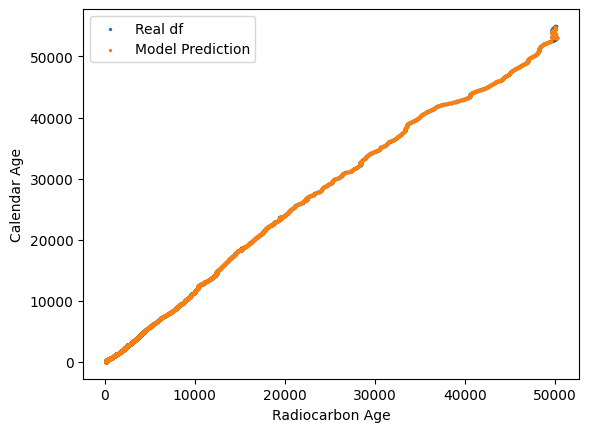

In [39]:
import matplotlib.pyplot as plt

plt.scatter(df['c14_age'], df['cal_bp'], s=2, label="Real df")

pred_line = model1.predict(X1)

plt.scatter(df['c14_age'], pred_line, s=2, label="Model Prediction")

plt.xlabel("Radiocarbon Age")
plt.ylabel("Calendar Age")
plt.legend()

plt.show()

Build the Age Calculator Function

This is the actual tool/
Input:

C14/C12 ratio

Output:

calibrated age

In [19]:

def estimate_age_from_ratio(ratio):

    F14C = ratio

    # compute radiocarbon age
    c14_age = -8033 * np.log(F14C)

    # estimate Δ14C
    delta14c = (F14C - 1) * 1000

    # predict calibration offset
    offset = model.predict([[F14C, c14_age, delta14c]])[0]

    # calibrated age
    cal_age = c14_age + offset

    return cal_age

test 

In [20]:
age = estimate_age_from_ratio(0.4)

print("Estimated calibrated age:", age, "years BP")

Estimated calibrated age: 7456.753449145087 years BP


c:\Users\lenovo\Desktop\mainr\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Feature Importance

This tells which variables matter most.

In [21]:
import pandas as pd

importance = model.feature_importances_

print(pd.Series(importance, index=X.columns))

F14C        0.075010
c14_age     0.851123
delta14c    0.073867
dtype: float64


plot of sorted


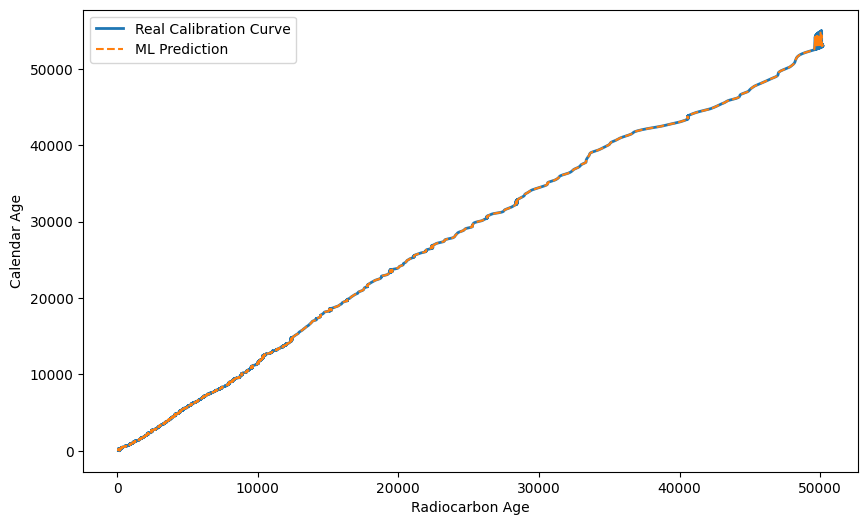

In [40]:
import numpy as np
import matplotlib.pyplot as plt

data_sorted = df.sort_values(by='c14_age')

X_sorted = data_sorted[['c14_age']]
y_sorted = data_sorted['cal_bp']
pred_curve = model1.predict(X_sorted)

plt.figure(figsize=(10,6))

plt.plot(X_sorted, y_sorted, label="Real Calibration Curve", linewidth=2)

plt.plot(X_sorted, pred_curve, label="ML Prediction", linestyle="dashed")

plt.xlabel("Radiocarbon Age")
plt.ylabel("Calendar Age")

plt.legend()
plt.show()

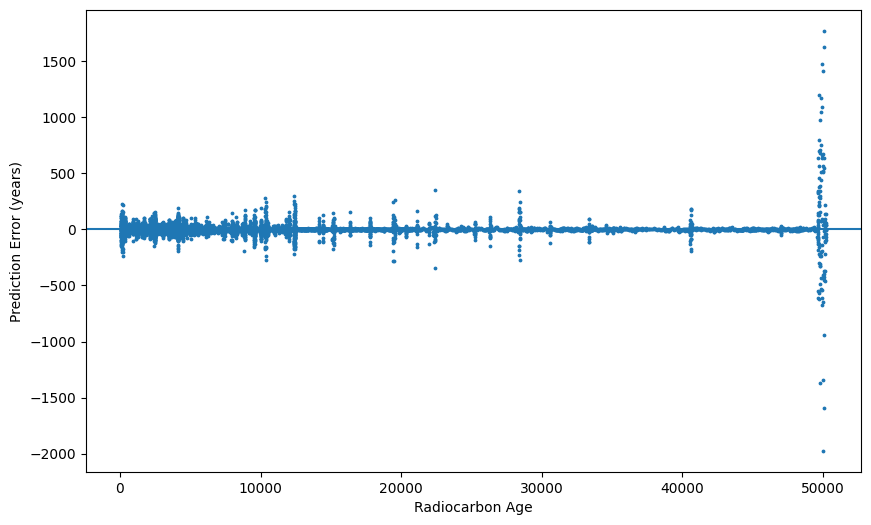

In [41]:
errors = y_sorted - pred_curve

plt.figure(figsize=(10,6))

plt.scatter(X_sorted, errors, s=3)

plt.axhline(0)

plt.xlabel("Radiocarbon Age")
plt.ylabel("Prediction Error (years)")

plt.show()